In [1]:
%load_ext dotenv 
%dotenv
%load_ext mypy_ipython
import config
from langgraph.graph import START, END, StateGraph,MessagesState
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, RemoveMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver

cannot find .env file


C:\Users\moham\anaconda3\envs\langgraph_env\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
#Define State
class State(MessagesState):
    summary: str

In [3]:
#Define Nodes
chat = ChatOpenAI(
    model="gpt-3.5-turbo",
    seed= 365,
    temperature=0,
    max_completion_tokens=50,
    openai_api_key = config.api_key
)

In [5]:
def ask_question (state: State) -> State:
    print(f"\n--------> ENTERING ask_question")
    
    question = "What is your question ?"
    print(question)
    return State(messages = [AIMessage(question), HumanMessage(input())])
    

In [6]:
def chatbot (state: State) -> State:
    print(f"\n--------> ENTERING CHATBOT")
    for i in state["messages"]:
        i.pretty_print()

    system_messages = f'''
    Here's a quick summary of what's been discussed so far: {state.get("summary", " ")}
    
    keep this in mind as you answer the next question. 
    '''
    response = chat.invoke( [SystemMessage(system_messages)]+state["messages"])
    response.pretty_print()

    return State(messages = [response])

In [7]:
def summarize_and_delete_msg (state:State) -> State:
    print(f"\n--------> ENTERING trim_messages:")
    
    new_conversation= ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"


    summary_instructions =f'''
    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result reflects the most recent
    context and developments.

    Previous_summary:
    {state.get("summary", "")}

    New_Conversation:
    {new_conversation}
    '''
    print(summary_instructions)
    summary = chat.invoke([HumanMessage(summary_instructions)])
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]] #Modify the remove messages variable so all messages in the state are deleted.


    return State(messages = remove_messages, summary= summary.content) 

In [11]:
#Define graph
graph = StateGraph(State) ## here pass the schema i.e state class defined above

In [12]:
graph.add_node("ask_question", ask_question)

graph.add_node("chatbot", chatbot)
graph.add_node("summarize_and_delete_msg", summarize_and_delete_msg)

graph.add_edge(START , "ask_question")
graph.add_edge("ask_question" , "chatbot")
graph.add_edge("chatbot" , "summarize_and_delete_msg")
graph.add_edge("summarize_and_delete_msg", END)

In [15]:
checkpointer = InMemorySaver()
grpah_compiled = graph.compile(checkpointer)

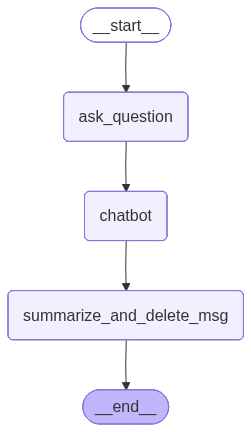

In [16]:
grpah_compiled

Now that we've set up the checkpointing mechanism, we need to define a thread to group and persist
those checkpoints.

In [19]:
config1 = {"configurable": {"thread_id": "1"}}

Next, we invoke the compiled graph in the standard way, passing an instance of the state class as

an argument.

We also provide the config one dictionary as configuration.

This instructs the graph to create in-memory checkpoints and associate them with the specific thread,

enabling thread level persistence.



In [22]:
grpah_compiled.invoke(State(), config1)


--------> ENTERING ask_question
What is your question ?


 what year was he born



--------> ENTERING CHATBOT
================================== Ai Message ==================================

What is your question ?
================================ Human Message =================================

what year was he born
================================== Ai Message ==================================

Gandhi was born on October 2, 1869.

--------> ENTERING trim_messages:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result reflects the most recent
    context and developments.

    Previous_summary:
    world. Gandhi's philosophy of Satyagraha, or truth force, emphasized the power of truth and nonviolence in bringing about social and political change. He played a key role in India's independence in 1947 and his legacy continues to

    New_Conversation:
    ai: What is your question ?

human: what year was he born

ai: Gandhi was born on October 2, 1869.


 

{'messages': [],
 'summary': 'Continuing from the previous summary, Mahatma Gandhi was born on October 2, 1869. His philosophy of Satyagraha, or truth force, emphasized the power of truth and nonviolence in bringing about social and political change'}

In [21]:
#we have to re reun the above cell

config2 = {"configurable": {"thread_id": "2"}}
grpah_compiled.invoke(State(), config2)

AT THIS TIME IT WILL FORGET THE CONFIG1 STUFF


## STATE OF THE SNAP SHOTS

In [24]:
graph_states = grpah_compiled.get_state_history(config1)

In [25]:
graph_states

<generator object Pregel.get_state_history at 0x000001D18AC24F60>

In [26]:
#since its a generator, So let's redefine graph states as a list of states.

In [27]:
graph_statesog = [i for i in grpah_compiled.get_state_history(config1)] 

In [29]:
for i in graph_statesog:
    print(i)

StateSnapshot(values={'messages': [], 'summary': 'Continuing from the previous summary, Mahatma Gandhi was born on October 2, 1869. His philosophy of Satyagraha, or truth force, emphasized the power of truth and nonviolence in bringing about social and political change'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f147d5f-24a5-6643-8008-9354ccb4cb1f'}}, metadata={'source': 'loop', 'step': 8, 'parents': {}}, created_at='2026-05-04T16:26:04.376019+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f147d5f-1289-6b53-8007-fe61680aeee4'}}, tasks=(), interrupts=())
StateSnapshot(values={'messages': [AIMessage(content='What is your question ?', additional_kwargs={}, response_metadata={}, id='50cf2c0c-11dd-4a48-bcf4-1e8fe386d11c', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='what year was he born', additional_kwargs={}, response_metadata={}, id='4d98a861-3212-44c4-a9ed-6b50d8b70b48')

First, reverse the items in the list so that we print the states from the beginning of the conversation

onwards.

You can do it like so.

Then set an f string as an argument for the print statement.

For each state, let's include the messages.

List the summary.

The next node to execute, and the step number.



In [31]:
for i in graph_statesog[::-1]:
    print(f'''
Messages: {i.values["messages"]}
Summary: {i.values.get("summary", "")}
Next: {i.next}
Step: {i.metadata["step"]}       
         '''
    )


Messages: []
Summary: 
Next: ('__start__',)
Step: -1       
         

Messages: []
Summary: 
Next: ('ask_question',)
Step: 0       
         

Messages: [AIMessage(content='What is your question ?', additional_kwargs={}, response_metadata={}, id='5746a7f2-e295-40fa-b001-19a68f598d0c', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='who is gandhi', additional_kwargs={}, response_metadata={}, id='2a2d2a0f-56b8-4694-9b65-eb0fa1f26a09')]
Summary: 
Next: ('chatbot',)
Step: 1       
         

Messages: [AIMessage(content='What is your question ?', additional_kwargs={}, response_metadata={}, id='5746a7f2-e295-40fa-b001-19a68f598d0c', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='who is gandhi', additional_kwargs={}, response_metadata={}, id='2a2d2a0f-56b8-4694-9b65-eb0fa1f26a09'), AIMessage(content='Gandhi, also known as Mahatma Gandhi, was a prominent leader in the Indian independence movement against British colonial rule. He was known for his nonviolent resis